# Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from matplotlib.lines import Line2D
import warnings

## Domain contribution LLM and Expert evaluations metrics

In [2]:
# Domains
domains = [
    "Metagenomic",
    "Phylogeny",
    "Single_Cell",
    "Systems_biology",
    "Neuroimaging",
    "Genetic_variant",
    "Microscopy",
]

base_folder = "Confusion_matrix_free_text_annotation"

def summarize_metrics(tsv_path, domain_name):
    df = pd.read_csv(tsv_path, sep="\t")

    return {
        "domain": domain_name,
        "mean_precision": df["precision"].mean(),
        "std_precision": df["precision"].std(),
        "mean_recall": df["recall"].mean(),
        "std_recall": df["recall"].std(),
        "mean_f1": df["f1_score"].mean(),
        "std_f1": df["f1_score"].std(),
    }

def build_summary(source_type):
    """
    source_type: "LLM" or "expert"
    """

    summaries = []

    for domain in domains:

        file_name = f"{domain}_confusion_metrics_{source_type}.tsv"

        file_path = os.path.join(
            base_folder,
            domain,
            file_name
        )

        if not os.path.exists(file_path):
            print(f"Missing: {file_path}")
            continue

        summaries.append(
            summarize_metrics(file_path, domain)
        )

    df_summary = pd.DataFrame(summaries)

    total_row = {
        "domain": "Total",
        "mean_precision": df_summary["mean_precision"].mean(),
        "std_precision": df_summary["std_precision"].mean(),
        "mean_recall": df_summary["mean_recall"].mean(),
        "std_recall": df_summary["std_recall"].mean(),
        "mean_f1": df_summary["mean_f1"].mean(),
        "std_f1": df_summary["std_f1"].mean(),
    }

    df_summary = pd.concat([df_summary, pd.DataFrame([total_row])], ignore_index=True)

    if source_type.lower() == "llm":
        df_summary["source"] = "LLM"
    else:
        df_summary["source"] = "Expert"
        
    return df_summary.round(3)


summary_df_LLM = build_summary("LLM")
summary_df_expert = build_summary("expert")


combined_summary_df = pd.concat(
    [summary_df_LLM, summary_df_expert],
    ignore_index=True
)

# Put "source" column first
cols = ["source"] + [c for c in combined_summary_df.columns if c != "source"]
combined_summary_df = combined_summary_df[cols]

combined_summary_df

,source,domain,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1
0,LLM,Metagenomic,0.418,0.340,0.502,0.382,0.433,0.321
1,LLM,Phylogeny,0.321,0.337,0.412,0.403,0.340,0.331
2,LLM,Single_Cell,0.496,0.307,0.412,0.203,0.427,0.234
3,LLM,Systems_biology,0.718,0.326,0.617,0.247,0.645,0.263
4,LLM,Neuroimaging,0.333,0.401,0.279,0.340,0.284,0.343
5,LLM,Genetic_variant,0.458,0.388,0.621,0.431,0.490,0.376
6,LLM,Microscopy,0.297,0.293,0.362,0.318,0.298,0.270
7,LLM,Total,0.434,0.342,0.458,0.332,0.417,0.305
8,Expert,Metagenomic,0.849,0.285,0.876,0.277,0.846,0.265
9,Expert,Phylogeny,0.972,0.118,0.922,0.157,0.942,0.130


In [12]:
# Save
combined_summary_df.to_csv("Confusion_matrix_free_text_annotation/combined_metrics_summary.csv", index=False)

#### Plot Recall, Precision and F1_score

In [13]:
def plot_metric_by_domain_with_values(combined_summary_df, metric_name, save_path=None):
    """
    combined_summary_df must contain:
    columns = [source, domain, mean_precision, std_precision, mean_recall, std_recall, mean_f1, std_f1]
    metric_name = "Precision", "Recall", or "F1"
    save_path = folder where PNG will be saved (optional)
    """
    
    # Map metric name to column names
    metric_map = {
        "Precision": ("mean_precision", "std_precision"),
        "Recall": ("mean_recall", "std_recall"),
        "F1": ("mean_f1", "std_f1")
    }
    
    if metric_name not in metric_map:
        raise ValueError("metric_name must be 'Precision', 'Recall', or 'F1'")
    
    mean_col, std_col = metric_map[metric_name]
    
    # Map metric name to y-axis label
    yaxis_label_map = {
        "Precision": "Precision",
        "Recall": "Recall",
        "F1": "F1_score"
    }
    yaxis_label = yaxis_label_map[metric_name]
    
    domains = [d for d in combined_summary_df["domain"].unique() if d != "Total"] + ["Overall mean"]
    x = np.arange(len(domains))
    width = 0.35
    
    llm_vals, llm_errs = [], []
    expert_vals, expert_errs = [], []
    
    for d in domains:
        lookup_domain = "Total" if d == "Overall mean" else d
        
        llm = combined_summary_df[
            (combined_summary_df["domain"] == lookup_domain) & 
            (combined_summary_df["source"] == "LLM")
        ]
        
        expert = combined_summary_df[
            (combined_summary_df["domain"] == lookup_domain) & 
            (combined_summary_df["source"] == "Expert")
        ]
        
        if len(llm) > 0:
            llm_vals.append(llm[mean_col].values[0])
            llm_errs.append(llm[std_col].values[0])
        else:
            llm_vals.append(0)
            llm_errs.append(0)
            
        if len(expert) > 0:
            expert_vals.append(expert[mean_col].values[0])
            expert_errs.append(expert[std_col].values[0])
        else:
            expert_vals.append(0)
            expert_errs.append(0)
    
    llm_vals = np.array(llm_vals)
    llm_errs = np.array(llm_errs)
    expert_vals = np.array(expert_vals)
    expert_errs = np.array(expert_errs)
    
    llm_upper = np.clip(llm_vals + llm_errs, 0, 1)
    llm_lower = np.clip(llm_vals - llm_errs, 0, 1)
    expert_upper = np.clip(expert_vals + expert_errs, 0, 1)
    expert_lower = np.clip(expert_vals - expert_errs, 0, 1)
    
    llm_errs_clipped = np.vstack([llm_vals - llm_lower, llm_upper - llm_vals])
    expert_errs_clipped = np.vstack([expert_vals - expert_lower, expert_upper - expert_vals])
    
    plt.figure(figsize=(14, 6))
    
    bars_llm = plt.bar(
        x - width/2,
        llm_vals,
        width,
        yerr=llm_errs_clipped,
        capsize=4,
        label="LLM",
        color='#4C72B0'
    )
    
    bars_expert = plt.bar(
        x + width/2,
        expert_vals,
        width,
        yerr=expert_errs_clipped,
        capsize=4,
        label="Expert",
        color='#DD8452'
    )
    
    def annotate_bars(bars, means, stds):
        for bar, mean, std in zip(bars, means, stds):
            x_pos = bar.get_x() + bar.get_width()/2
            plt.text(
                x_pos,
                -0.03,
                f"{mean:.2f}\n± {std:.2f}",
                ha="center",
                va="top",
                fontsize=9
            )
    
    annotate_bars(bars_llm, llm_vals, llm_errs)
    annotate_bars(bars_expert, expert_vals, expert_errs)
    
    plt.xticks(x, domains, rotation=45, ha="right")
    plt.ylabel(yaxis_label)  
    plt.ylim(-0.15, 1.05)
    plt.legend()
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    if save_path is not None:
        os.makedirs(save_path, exist_ok=True)
        filename = f"{metric_name}_by_domain.png"
        full_path = os.path.join(save_path, filename)
        plt.savefig(
            full_path,
            dpi=600,
            bbox_inches="tight",
            facecolor="white"
        )
        print(f"Saved to: {full_path}")
    
    plt.show()

Saved to: ./plots/Precision_by_domain.png


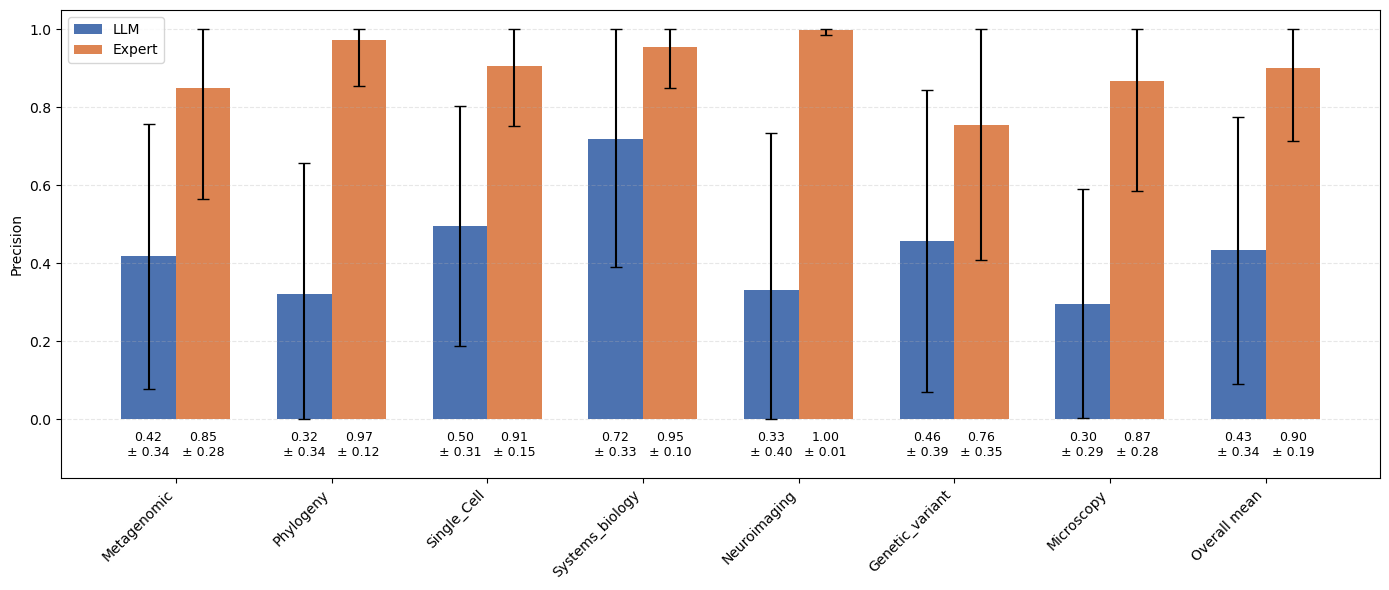

Saved to: ./plots/Recall_by_domain.png


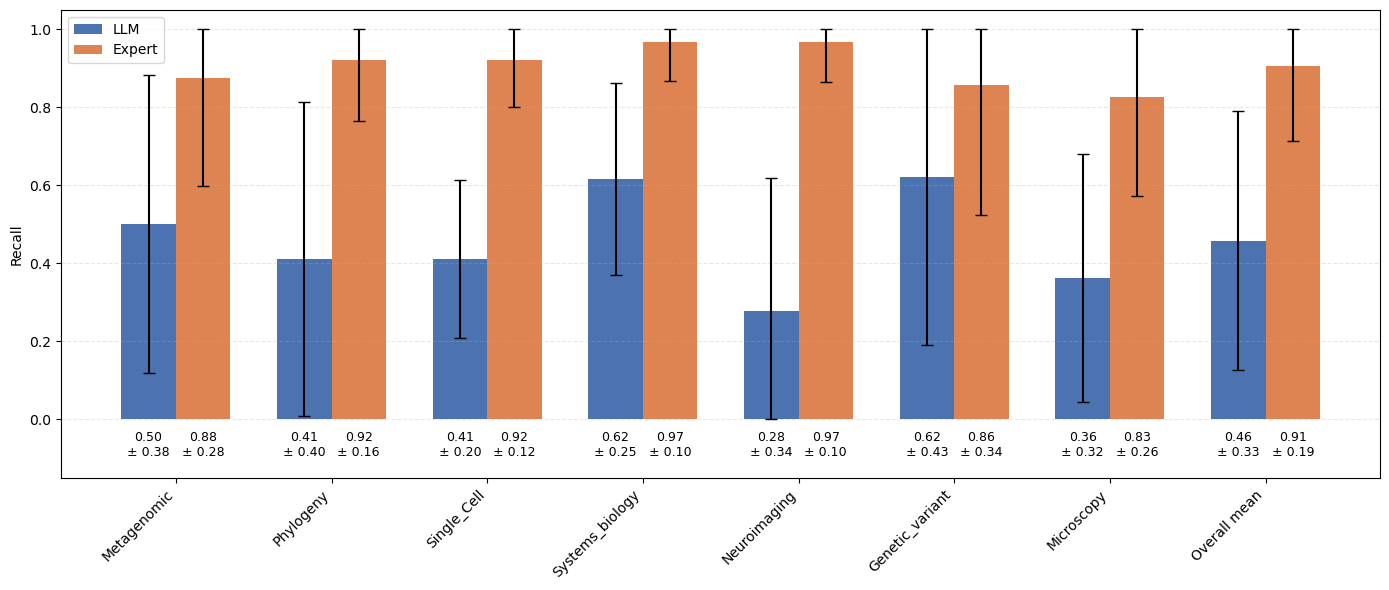

Saved to: ./plots/F1_by_domain.png


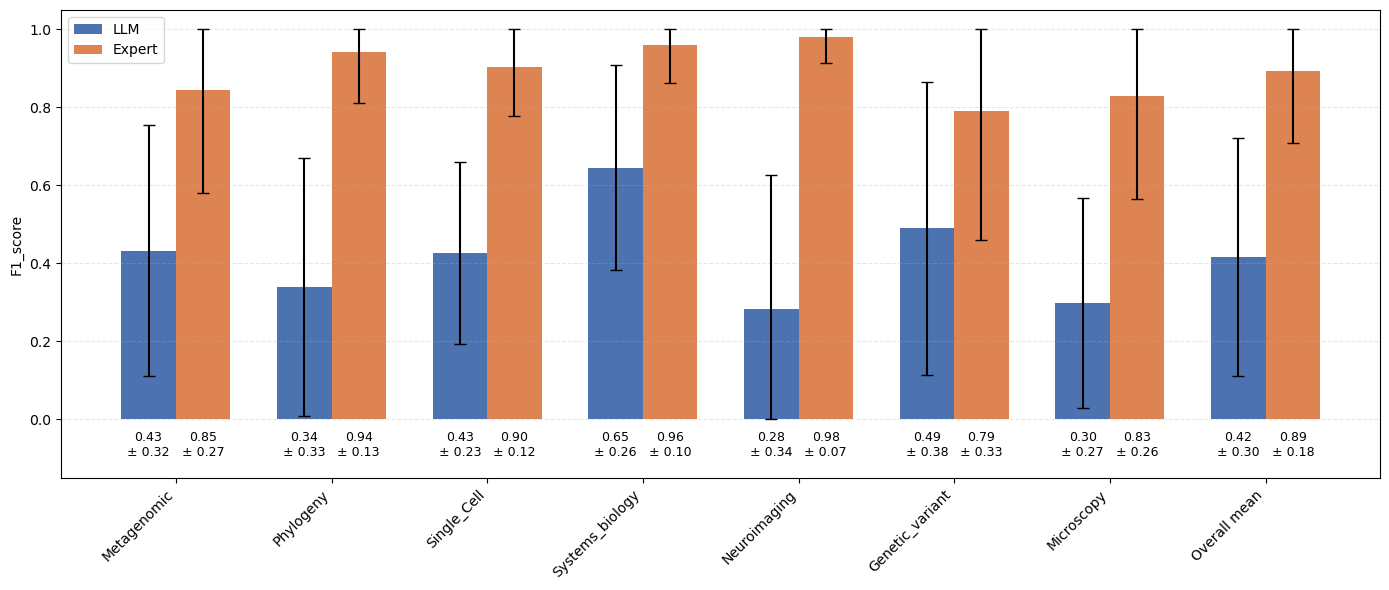

In [14]:
# Plot Precision
plot_metric_by_domain_with_values(combined_summary_df, "Precision", save_path="./plots")

# Plot Recall
plot_metric_by_domain_with_values(combined_summary_df, "Recall", save_path="./plots")

# Plot F1
plot_metric_by_domain_with_values(combined_summary_df, "F1", save_path="./plots")

#### Count retention, rejection and mixed annotations

In [16]:

files_LLM = {
    "Metagenomic": "Confusion_matrix_free_text_annotation/Metagenomic/Metagenomic_confusion_metrics_LLM.tsv",
    "Phylogeny": "Confusion_matrix_free_text_annotation/Phylogeny/Phylogeny_confusion_metrics_LLM.tsv",
    "Single_Cell": "Confusion_matrix_free_text_annotation/Single_Cell/Single_Cell_confusion_metrics_LLM.tsv",
    "Systems_biology": "Confusion_matrix_free_text_annotation/Systems_biology/Systems_biology_confusion_metrics_LLM.tsv",
    "Neuroimaging": "Confusion_matrix_free_text_annotation/Neuroimaging/Neuroimaging_confusion_metrics_LLM.tsv",
    "Genetic_variant": "Confusion_matrix_free_text_annotation/Genetic_variant/Genetic_variant_confusion_metrics_LLM.tsv",
    "Microscopy": "Confusion_matrix_free_text_annotation/Microscopy/Microscopy_confusion_metrics_LLM.tsv",
}

files_expert = {
    "Metagenomic": "Confusion_matrix_free_text_annotation/Metagenomic/Metagenomic_confusion_metrics_expert.tsv",
    "Phylogeny": "Confusion_matrix_free_text_annotation/Phylogeny/Phylogeny_confusion_metrics_expert.tsv",
    "Single_Cell": "Confusion_matrix_free_text_annotation/Single_Cell/Single_Cell_confusion_metrics_expert.tsv",
    "Systems_biology": "Confusion_matrix_free_text_annotation/Systems_biology/Systems_biology_confusion_metrics_expert.tsv",
    "Neuroimaging": "Confusion_matrix_free_text_annotation/Neuroimaging/Neuroimaging_confusion_metrics_expert.tsv",
    "Genetic_variant": "Confusion_matrix_free_text_annotation/Genetic_variant/Genetic_variant_confusion_metrics_expert.tsv",
    "Microscopy": "Confusion_matrix_free_text_annotation/Microscopy/Microscopy_confusion_metrics_expert.tsv"
}

In [17]:
def summarize_domain(domain):

    df_llm = pd.read_csv(files_LLM[domain], sep="\t")
    df_exp = pd.read_csv(files_expert[domain], sep="\t")

    llm_total = df_llm["deepseek_total"].sum()
    llm_retained = df_llm["deepseek_retained_in_consensus"].sum()
    llm_rejected = df_llm["deepseek_not_retained"].sum()
    mixed = df_llm["mixed_annotations_count"].sum()

    llm_retention_rate = llm_retained / llm_total if llm_total else 0
    llm_rejection_rate = llm_rejected / llm_total if llm_total else 0
    mixed_percentage = mixed / llm_total if llm_total else 0


    expert_total = df_exp["expert_total"].sum()
    expert_retained = df_exp["expert_retained_in_consensus"].sum()
    expert_rejected = df_exp["expert_not_retained"].sum()

    expert_retention_rate = expert_retained / expert_total if expert_total else 0
    expert_rejection_rate = expert_rejected / expert_total if expert_total else 0


    consensus_annotations = df_llm["TP"].sum() + df_llm["FN"].sum()

    return {

        "domain": domain,

        # LLM statistics
        "llm_total_annotations": llm_total,
        "llm_retained": llm_retained,
        "llm_rejected": llm_rejected,

        "llm_retention_rate": llm_retention_rate,
        "llm_rejection_rate": llm_rejection_rate,

        "mixed_annotations": mixed,
        "mixed_percentage": mixed_percentage,

        # expert statistics
        "expert_total_annotations": expert_total,
        "expert_retained": expert_retained,
        "expert_rejected": expert_rejected,

        "expert_retention_rate": expert_retention_rate,
        "expert_rejection_rate": expert_rejection_rate,

        # consensus size
        "consensus_annotations": consensus_annotations
    }


summaries = [summarize_domain(domain) for domain in files_LLM]

summary_df = pd.DataFrame(summaries).round(3)


global_stats = {

    "domain": "ALL_DOMAINS",

    # LLM global stats
    "llm_total_annotations": summary_df["llm_total_annotations"].sum(),
    "llm_retained": summary_df["llm_retained"].sum(),
    "llm_rejected": summary_df["llm_rejected"].sum(),

    "llm_retention_rate":
        summary_df["llm_retained"].sum() /
        summary_df["llm_total_annotations"].sum(),

    "llm_rejection_rate":
        summary_df["llm_rejected"].sum() /
        summary_df["llm_total_annotations"].sum(),

    "mixed_annotations": summary_df["mixed_annotations"].sum(),

    "mixed_percentage":
        summary_df["mixed_annotations"].sum() /
        summary_df["llm_total_annotations"].sum(),

    # Expert global stats
    "expert_total_annotations": summary_df["expert_total_annotations"].sum(),
    "expert_retained": summary_df["expert_retained"].sum(),
    "expert_rejected": summary_df["expert_rejected"].sum(),

    "expert_retention_rate":
        summary_df["expert_retained"].sum() /
        summary_df["expert_total_annotations"].sum(),

    "expert_rejection_rate":
        summary_df["expert_rejected"].sum() /
        summary_df["expert_total_annotations"].sum(),

    # total consensus annotations
    "consensus_annotations": summary_df["consensus_annotations"].sum()
}

summary_df = pd.concat(
    [summary_df, pd.DataFrame([global_stats])],
    ignore_index=True
).round(3)

In [18]:
summary_df

,domain,llm_total_annotations,llm_retained,llm_rejected,llm_retention_rate,llm_rejection_rate,mixed_annotations,mixed_percentage,expert_total_annotations,expert_retained,expert_rejected,expert_retention_rate,expert_rejection_rate,consensus_annotations
0,Metagenomic,146,44,102,0.301,0.699,22,0.151,134,110,24,0.821,0.179,139
1,Phylogeny,53,12,41,0.226,0.774,4,0.075,32,31,1,0.969,0.031,40
2,Single_Cell,77,33,44,0.429,0.571,10,0.130,85,74,11,0.871,0.129,102
3,Systems_biology,284,193,91,0.680,0.320,11,0.039,173,156,17,0.902,0.098,323
4,Neuroimaging,100,22,78,0.220,0.780,3,0.030,101,100,1,0.990,0.010,109
5,Genetic_variant,200,71,129,0.355,0.645,12,0.060,114,77,37,0.675,0.325,122
6,Microscopy,84,15,69,0.179,0.821,10,0.119,71,54,17,0.761,0.239,67
7,ALL_DOMAINS,944,390,554,0.413,0.587,72,0.076,710,602,108,0.848,0.152,902


## Figures

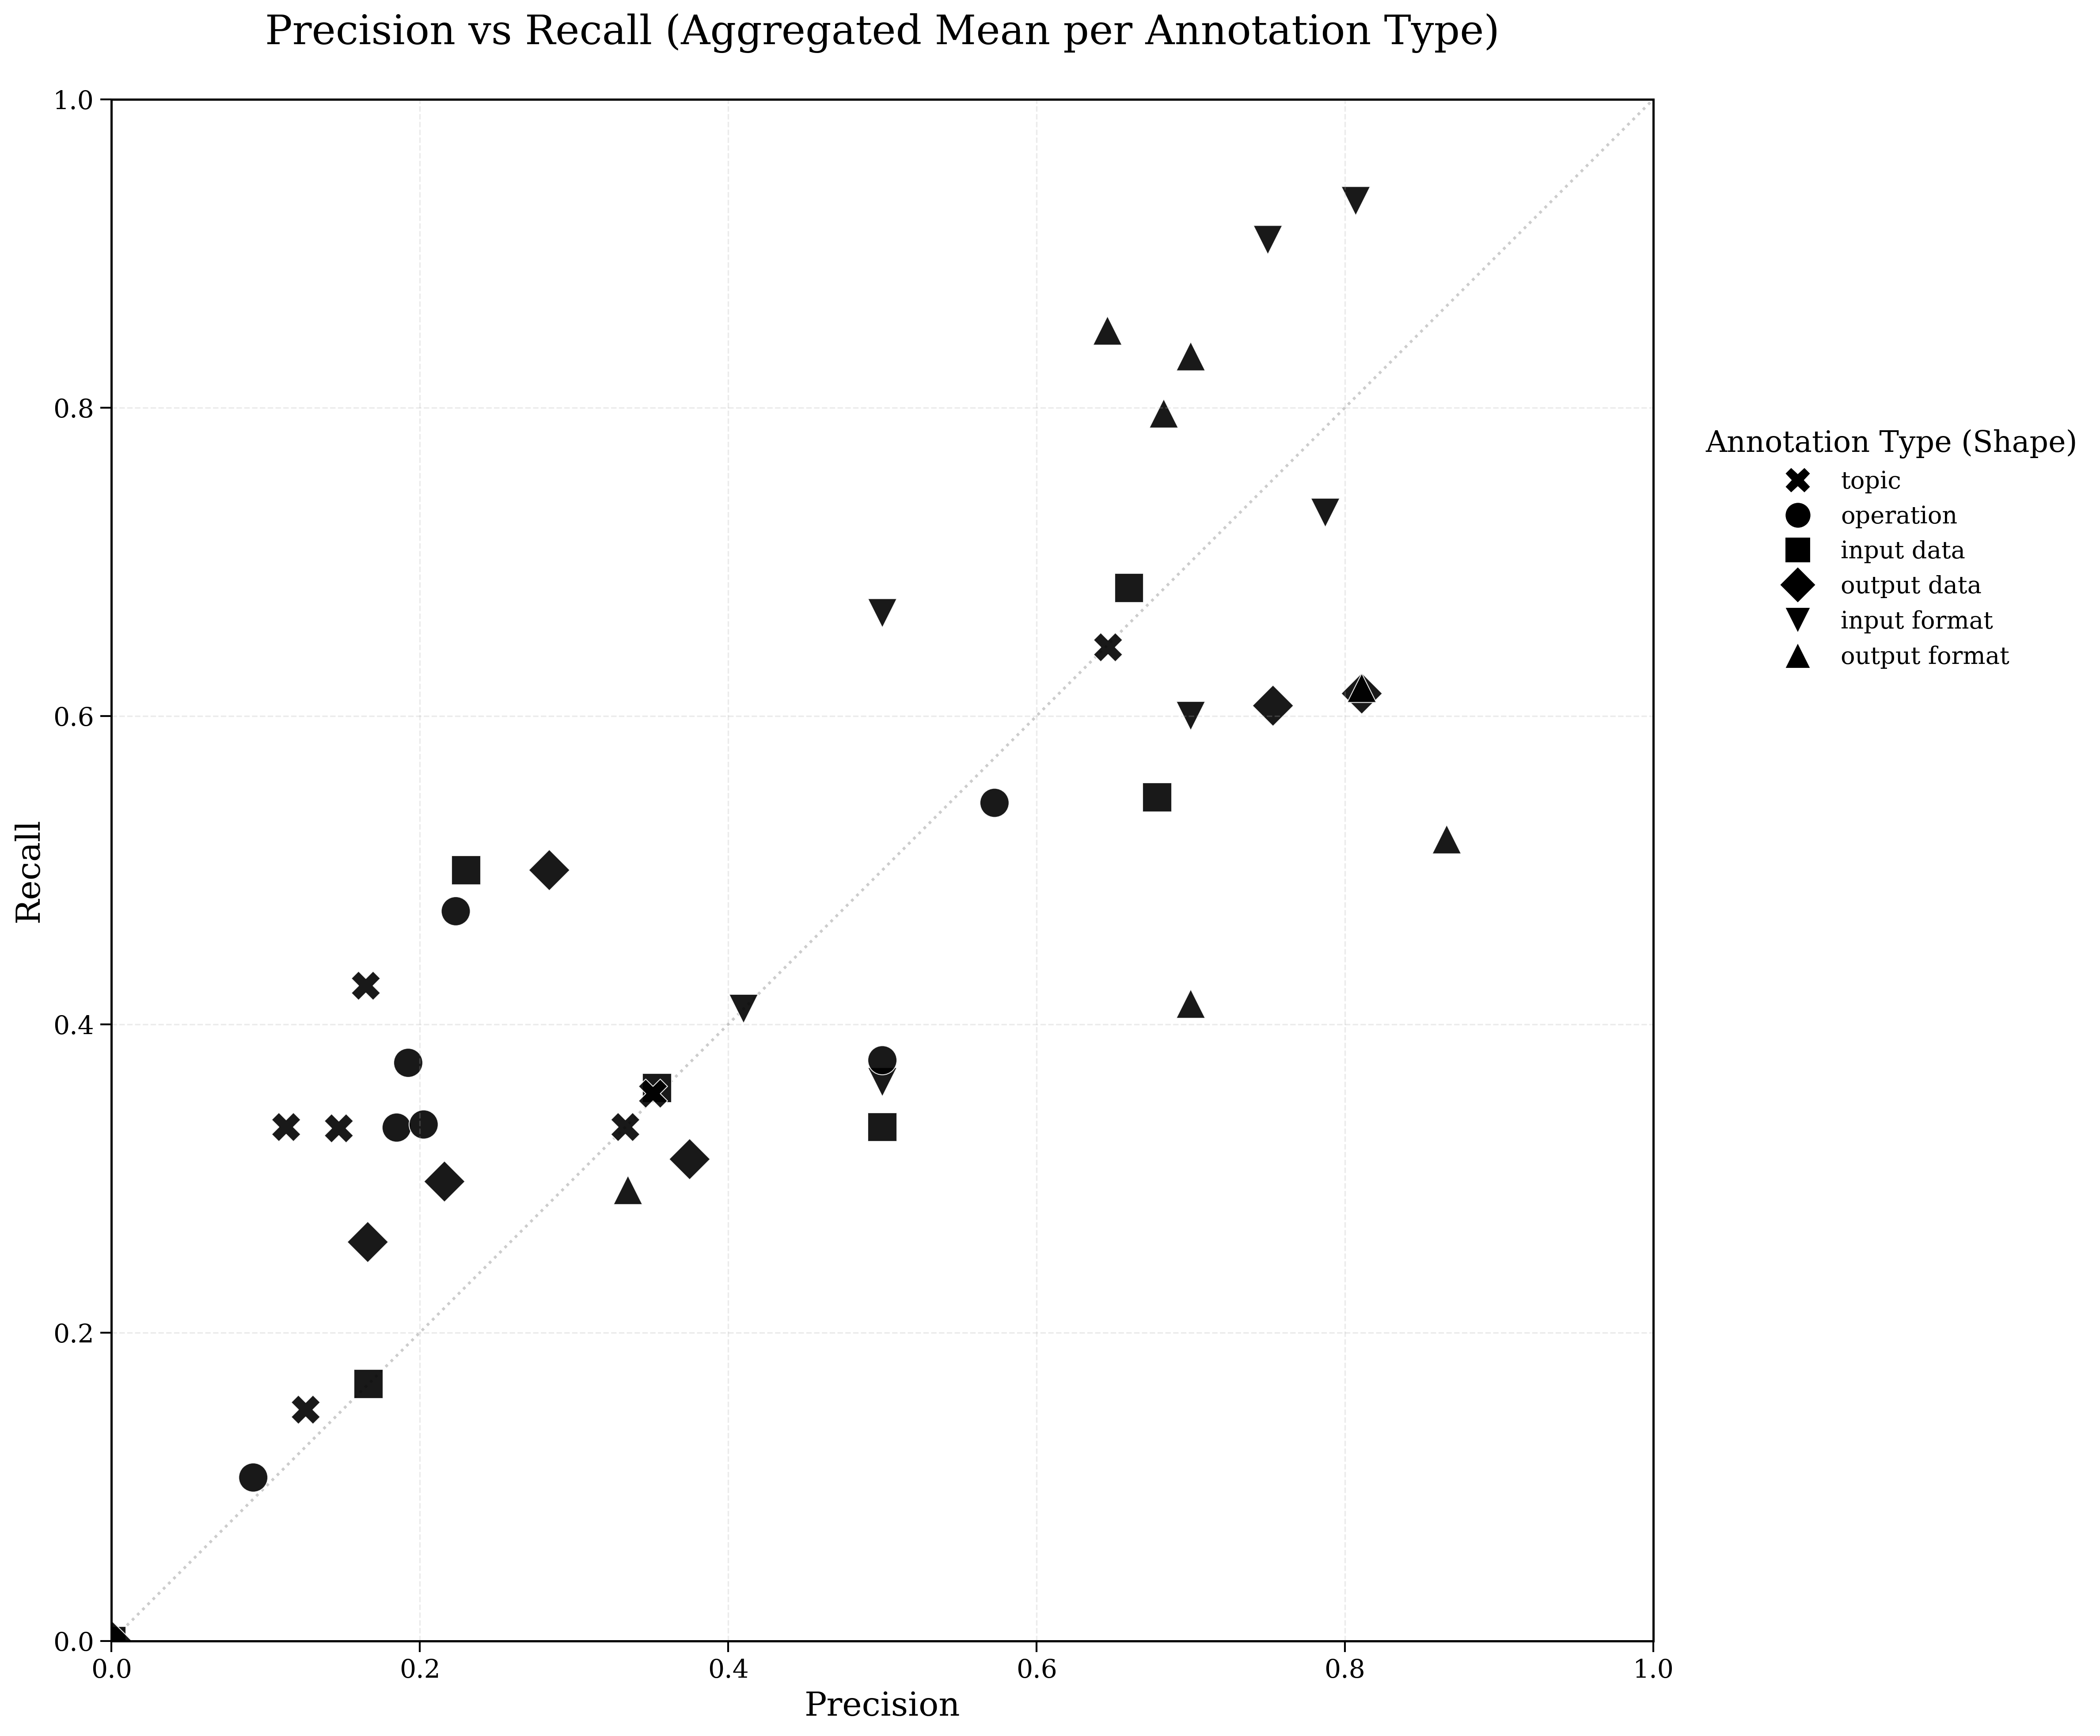

In [12]:
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib.font_manager')

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Georgia', 'serif'],
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'legend.title_fontsize': 14,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight'
})


domain_colors = {
    "Metagenomic": "#E69F00",
    "Phylogeny": "#56B4E9",
    "Single_Cell": "#009E73",
    "Systems_biology": "#F0E442",
    "Neuroimaging": "#0072B2",
    "Genetic_variant": "#D55E00",
    "Microscopy": "#CC79A7"
}

annotation_priority = {
    "topic": 1,
    "operation": 2,
    "input data": 3,
    "output data": 4,
    "input format": 5,
    "output format": 6
}

preferred_shapes = {
    "topic": 'X',             # Cross
    "operation": 'o',         # Round
    "input data": 's',        # Square
    "output data": 'D',       # Diamond
    "input format": 'v',      # Low Triangle
    "output format": '^'      # High Triangle
}

df_list = []
for domain, filepath in files_LLM.items():
    try:
        df = pd.read_csv(filepath, sep='\t')
        df['domain'] = domain
        df_list.append(df)
    except FileNotFoundError:
        print(f"Warning: File not found {filepath}")

all_metrics_df = pd.concat(df_list, ignore_index=True)

# Aggregate metrics
agg_metrics_df = all_metrics_df.groupby(
    ['annotation_type', 'domain'], as_index=False
)[['precision', 'recall', 'f1_score']].mean()

unique_annotations = agg_metrics_df['annotation_type'].unique()
annotation_markers = {
    ann: preferred_shapes.get(ann, 'o')  
    for ann in unique_annotations
}

plt.figure(figsize=(16, 16))

sns.scatterplot(
    data=agg_metrics_df,
    x='precision',
    y='recall',
    style='annotation_type',
    markers=annotation_markers,
    color='black',
    s=250,
    legend=False,
    edgecolor='white',
    linewidth=0.5,
    alpha=0.9
)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect('equal', adjustable='box')

plt.xlabel('Precision', fontsize=18)
plt.ylabel('Recall', fontsize=18)
plt.title('Precision vs Recall (Aggregated Mean per Annotation Type)', fontsize=22, pad=30)

plt.grid(True, linestyle='--', alpha=0.25, linewidth=0.8)
plt.tick_params(axis='both', which='major', labelsize=14, length=6, width=1)

sorted_annos = sorted(
    unique_annotations, 
    key=lambda x: annotation_priority.get(x, 99)
)

anno_handles = [
    Line2D([0], [0], marker=annotation_markers[a], color='k', linestyle='None', 
           markersize=14, label=a, markerfacecolor='black',
           markeredgecolor='white', markeredgewidth=0.5)
    for a in sorted_annos
]

leg_annotations = plt.legend(
    handles=anno_handles, 
    title="Annotation Type (Shape)", 
    title_fontsize=16,
    fontsize=13,
    loc='upper left',
    bbox_to_anchor=(1.02, 0.8),
    frameon=False,
    columnspacing=1.5,
    handletextpad=0.8
)

# Diagonal reference line
plt.plot([0, 1], [0, 1], linestyle=':', color='gray', linewidth=1.5, alpha=0.4, zorder=0)

plt.tight_layout()
plt.show()

=== Shape Assignment ===
  'input data' -> 's'
  'input format' -> 'v'
  'operation' -> 'o'
  'output data' -> 'D'
  'output format' -> '^'
  'topic' -> 'X'


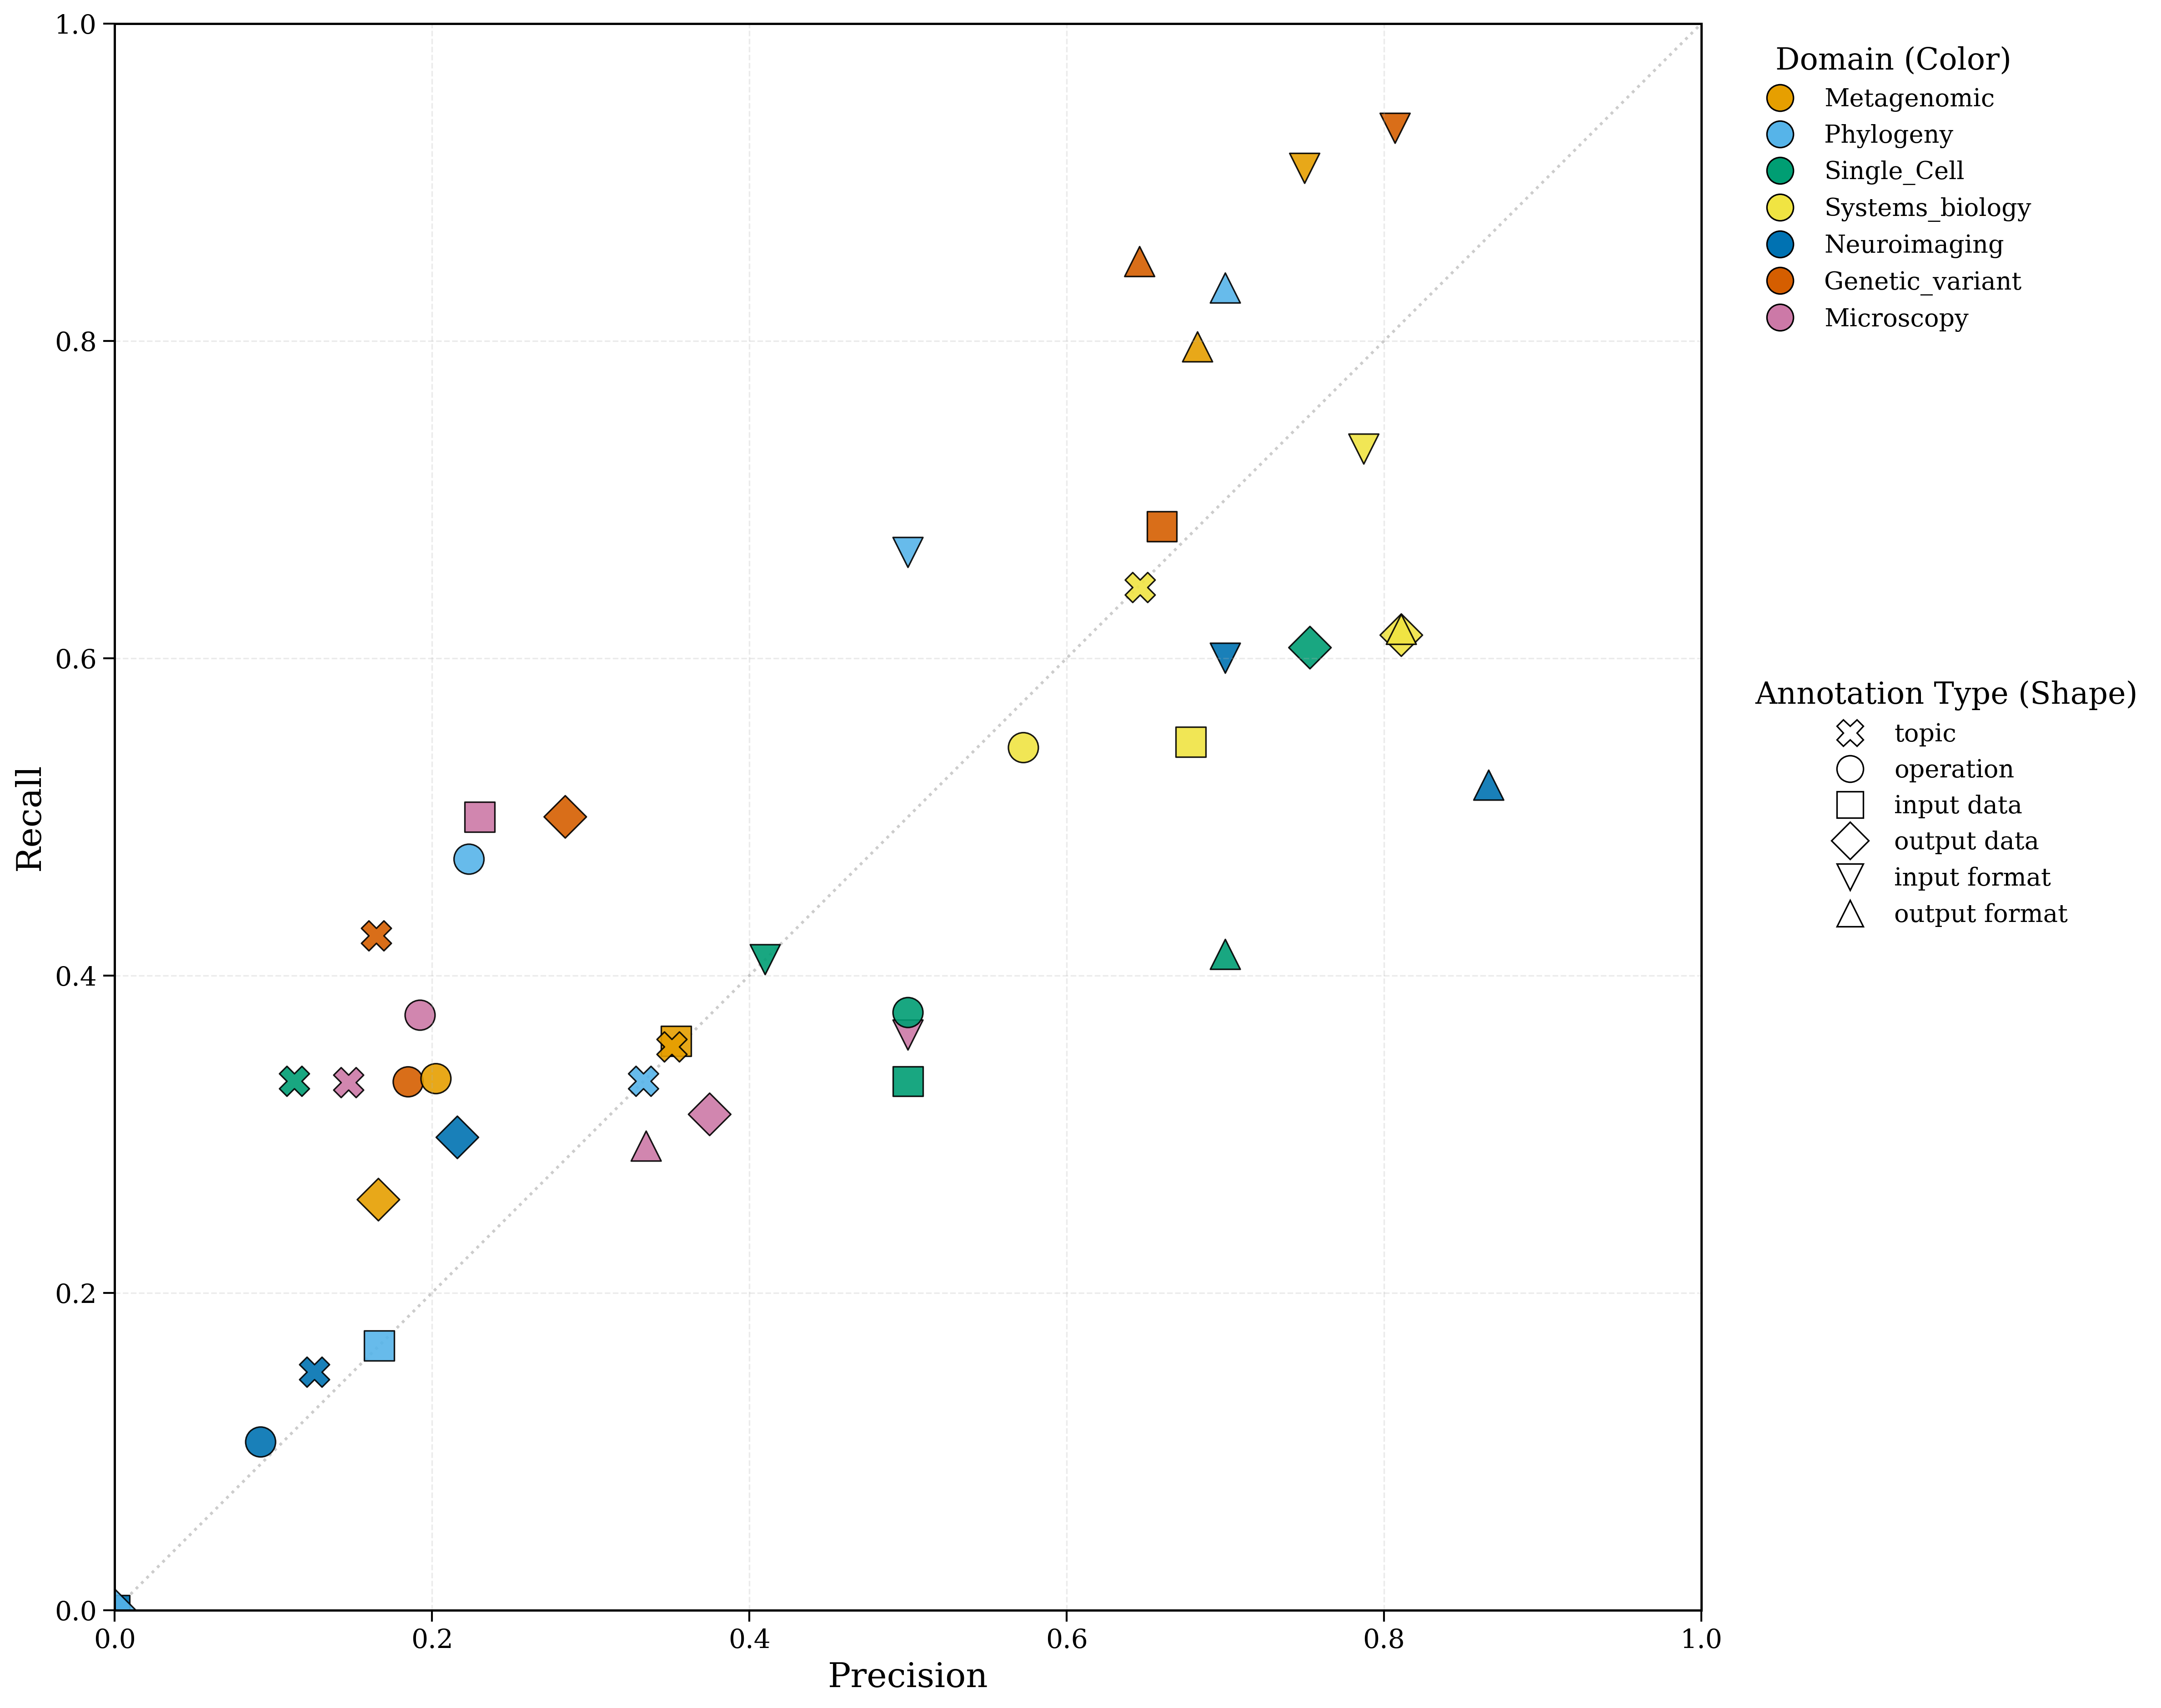

In [ ]:
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib.font_manager')

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Georgia', 'serif'],
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'legend.title_fontsize': 14,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight'
})


files_LLM = {
    "Metagenomic": "Confusion_matrix_free_text_annotation/Metagenomic/Metagenomic_confusion_metrics_LLM.tsv",
    "Phylogeny": "Confusion_matrix_free_text_annotation/Phylogeny/Phylogeny_confusion_metrics_LLM.tsv",
    "Single_Cell": "Confusion_matrix_free_text_annotation/Single_Cell/Single_Cell_confusion_metrics_LLM.tsv",
    "Systems_biology": "Confusion_matrix_free_text_annotation/Systems_biology/Systems_biology_confusion_metrics_LLM.tsv",
    "Neuroimaging": "Confusion_matrix_free_text_annotation/Neuroimaging/Neuroimaging_confusion_metrics_LLM.tsv",
    "Genetic_variant": "Confusion_matrix_free_text_annotation/Genetic_variant/Genetic_variant_confusion_metrics_LLM.tsv",
    "Microscopy": "Confusion_matrix_free_text_annotation/Microscopy/Microscopy_confusion_metrics_LLM.tsv",
}


domain_colors = {
    "Metagenomic": "#E69F00",
    "Phylogeny": "#56B4E9",
    "Single_Cell": "#009E73",
    "Systems_biology": "#F0E442",
    "Neuroimaging": "#0072B2",
    "Genetic_variant": "#D55E00",
    "Microscopy": "#CC79A7"
}

annotation_priority = {
    "topic": 1,
    "operation": 2,
    "input data": 3,
    "output data": 4,
    "input format": 5,
    "output format": 6
}

preferred_shapes = {
    "topic": 'X',             # Cross
    "operation": 'o',         # Round
    "input data": 's',        # Square
    "output data": 'D',       # Diamond
    "input format": 'v',      # Low Triangle (points down)
    "output format": '^'      # High Triangle (points up)
}

df_list = []
for domain, filepath in files_LLM.items():
    try:
        df = pd.read_csv(filepath, sep='\t')
        df['domain'] = domain
        df_list.append(df)
    except FileNotFoundError:
        print(f"Warning: File not found {filepath}")

if not df_list:
    raise FileNotFoundError("No data files were loaded. Please check file paths.")

all_metrics_df = pd.concat(df_list, ignore_index=True)

# Aggregate metrics
agg_metrics_df = all_metrics_df.groupby(
    ['annotation_type', 'domain'], as_index=False
)[['precision', 'recall', 'f1_score']].mean()

# Prepare Markers
unique_annotations = agg_metrics_df['annotation_type'].unique()
annotation_markers = {
    ann: preferred_shapes.get(ann, 'o')  # Default to circle if unknown
    for ann in unique_annotations
}

print("=== Shape Assignment ===")
for ann, marker in annotation_markers.items():
    print(f"  '{ann}' -> '{marker}'")


plt.figure(figsize=(16, 16))

sns.scatterplot(
    data=agg_metrics_df,
    x='precision',
    y='recall',
    hue='domain',
    style='annotation_type',
    palette=domain_colors,
    markers=annotation_markers,
    s=250,
    legend=False,
    edgecolor='black',
    linewidth=0.8,
    alpha=0.9
)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect('equal', adjustable='box')

plt.xlabel('Precision', fontsize=18)
plt.ylabel('Recall', fontsize=18)

plt.grid(True, linestyle='--', alpha=0.25, linewidth=0.8)
plt.tick_params(axis='both', which='major', labelsize=14, length=6, width=1)

# Legend 1: Domains (Color)
domain_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=domain_colors[d], 
           markersize=14, label=d, markeredgecolor='black', markeredgewidth=0.8)
    for d in domain_colors.keys()
]

leg_domains = plt.legend(
    handles=domain_handles, 
    title="Domain (Color)", 
    title_fontsize=16,
    fontsize=13,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    columnspacing=1.5,
    handletextpad=0.8
)

# Legend 2: Annotations (Shape)
sorted_annos = sorted(
    unique_annotations, 
    key=lambda x: annotation_priority.get(x, 99)
)

anno_handles = [
    Line2D([0], [0], marker=annotation_markers[a], color='k', linestyle='None', 
           markersize=14, label=a, markerfacecolor='white', 
           markeredgecolor='black', markeredgewidth=0.8)
    for a in sorted_annos
]

leg_annotations = plt.legend(
    handles=anno_handles, 
    title="Annotation Type (Shape)", 
    title_fontsize=16,
    fontsize=13,
    loc='upper left',
    bbox_to_anchor=(1.02, 0.60),
    frameon=False,
    columnspacing=1.5,
    handletextpad=0.8
)

plt.gca().add_artist(leg_domains)

# Diagonal reference line
plt.plot([0, 1], [0, 1], linestyle=':', color='gray', linewidth=1.5, alpha=0.4, zorder=0)

plt.tight_layout()

#plt.savefig("plots/precision_recall_aggregated_mean_per_annotation_type_llm.png", dpi=600, bbox_inches='tight')
plt.savefig("plots/precision_recall_aggregated_mean_per_annotation_type.svg", bbox_inches='tight')

plt.show()